In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [2]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/24paso/consumption/24pasos_mlp_consumption.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2017-11-24 23:40:00,-0.616186,0.662075
2017-11-24 23:50:00,-0.689976,0.391910
2017-11-25 00:00:00,-0.791756,0.495324
2017-11-25 00:10:00,-0.867242,0.418324
2017-11-25 00:20:00,-0.961389,0.294306


In [3]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/24paso/consumption/24pasos_lstm_consumption.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2017-11-24 23:40:00,-0.616186,-0.452299
2017-11-24 23:50:00,-0.689976,-0.581890
2017-11-25 00:00:00,-0.791756,-0.628235
2017-11-25 00:10:00,-0.867242,-0.668937
2017-11-25 00:20:00,-0.961389,-0.715718


In [4]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/24paso/consumption/24pasos_gru_consumption.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2017-11-24 23:40:00,-0.616186,-0.388370
2017-11-24 23:50:00,-0.689976,-0.660478
2017-11-25 00:00:00,-0.791756,-0.686881
2017-11-25 00:10:00,-0.867242,-0.724484
2017-11-25 00:20:00,-0.961389,-0.770980


In [5]:
datosCross= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/24paso/consumption/crossformerConsumption.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-0.814439
2017-11-25 01:40:00,-1.345607,-0.834665
2017-11-25 01:50:00,-1.349847,-0.852647
2017-11-25 02:00:00,-1.400737,-0.874528
2017-11-25 02:10:00,-1.449083,-0.896216


In [6]:
datosI= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/24paso/consumption/itransformerConsumption.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.158689
2017-11-25 01:40:00,-1.345607,-1.198844
2017-11-25 01:50:00,-1.349847,-1.228719
2017-11-25 02:00:00,-1.400737,-1.233345
2017-11-25 02:10:00,-1.449083,-1.182126


In [7]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Tesis/pruebasEstadisticas/errores/NARX/24paso/consumption/tftConsumption.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2017-11-24 02:40:00,-1.447386,-1.321104
2017-11-24 02:50:00,-1.495731,-1.320792
2017-11-24 03:00:00,-1.527962,-1.319684
2017-11-24 03:10:00,-1.505909,-1.318097
2017-11-24 03:20:00,-1.527962,-1.315526


In [8]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])



In [9]:
final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-11-24 02:40:00,NaN,NaN,NaN,NaN,NaN,-0.126282
2017-11-24 02:50:00,NaN,NaN,NaN,NaN,NaN,-0.174939
2017-11-24 03:00:00,NaN,NaN,NaN,NaN,NaN,-0.208278
2017-11-24 03:10:00,NaN,NaN,NaN,NaN,NaN,-0.187813
2017-11-24 03:20:00,NaN,NaN,NaN,NaN,NaN,-0.212436


In [10]:
final = final.dropna()
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-11-25 01:30:00,-1.221161,-0.316441,-0.159408,-0.538801,-0.194551,-0.066074
2017-11-25 01:40:00,-1.107295,-0.267117,-0.121480,-0.510942,-0.146762,-0.042317
2017-11-25 01:50:00,-1.005739,-0.233801,-0.087897,-0.497200,-0.121128,-0.038647
2017-11-25 02:00:00,-1.025045,-0.262711,-0.129575,-0.526210,-0.167392,-0.084381
2017-11-25 02:10:00,-1.014057,-0.296637,-0.172249,-0.552866,-0.266956,-0.129584


Muestra aleatoria

In [11]:
final = final.sample(frac=0.10, random_state=42)

In [12]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [13]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print(p)


3.7410887846841574e-93


In [14]:
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print(p)


5.4888781794617236e-99


In [15]:
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print(p)


2.744016582182492e-96


In [16]:
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print(p)


1.5288007826127532e-70


In [17]:
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print(p)


7.260543699599319e-52


In [18]:
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print(p)


1.0377754482586602e-92


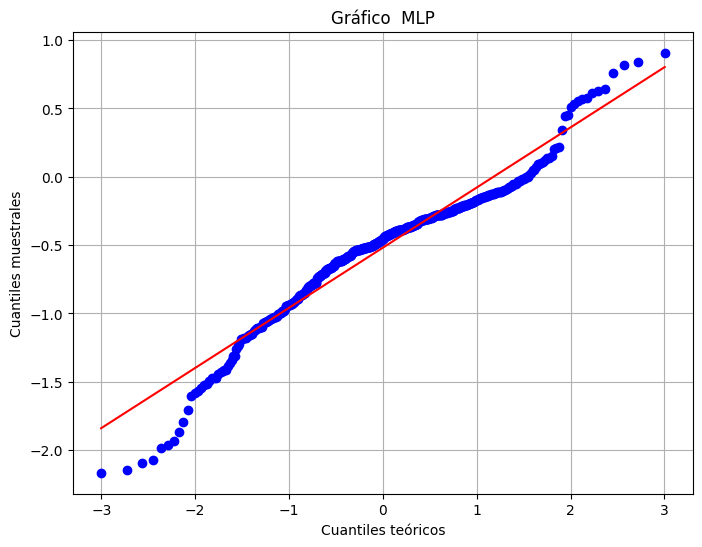

In [19]:
plt.figure(figsize=(8, 6))

stats.probplot(final["MLP"], dist="norm", plot=plt)
plt.title('Gráfico  MLP')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

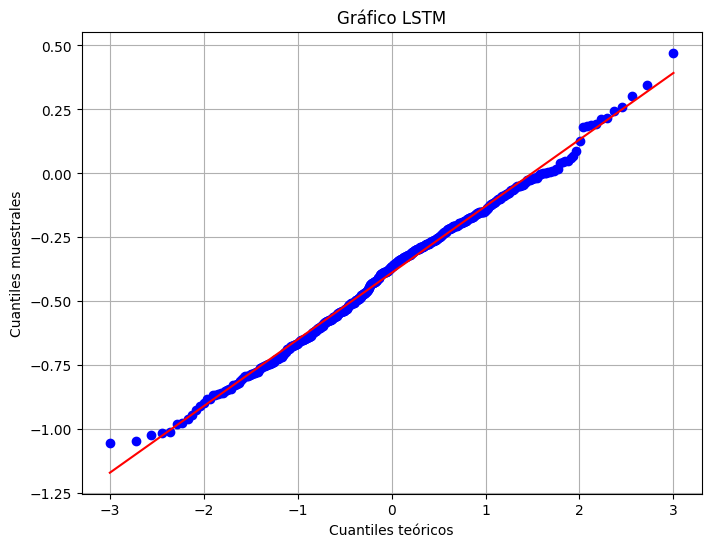

In [20]:
plt.figure(figsize=(8, 6))

stats.probplot(final["LSTM"], dist="norm", plot=plt)
plt.title('Gráfico LSTM')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

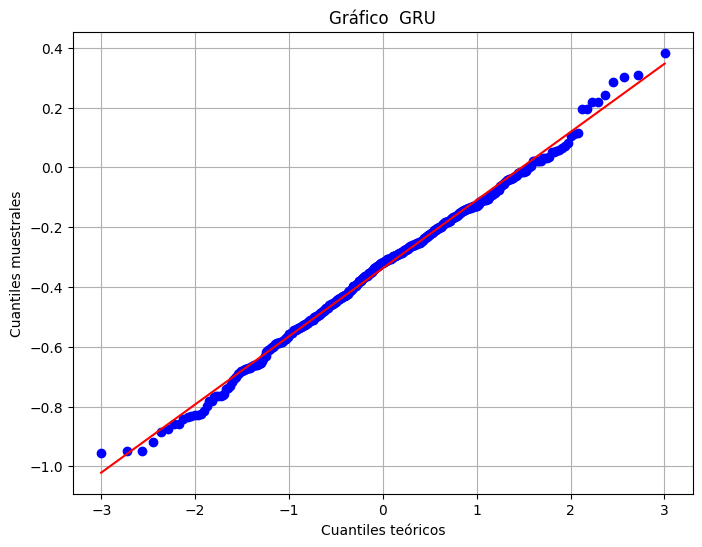

In [21]:
plt.figure(figsize=(8, 6))

stats.probplot(final["GRU"], dist="norm", plot=plt)
plt.title('Gráfico  GRU')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

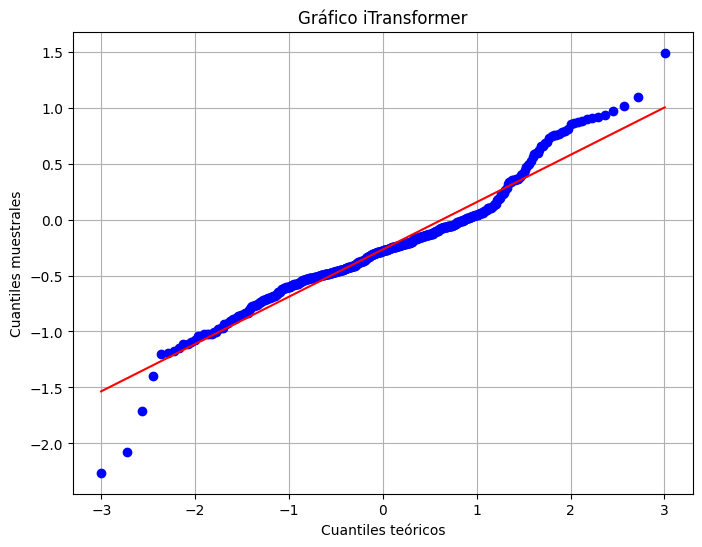

In [22]:
plt.figure(figsize=(8, 6))

stats.probplot(final["iTransformer"], dist="norm", plot=plt)
plt.title('Gráfico iTransformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

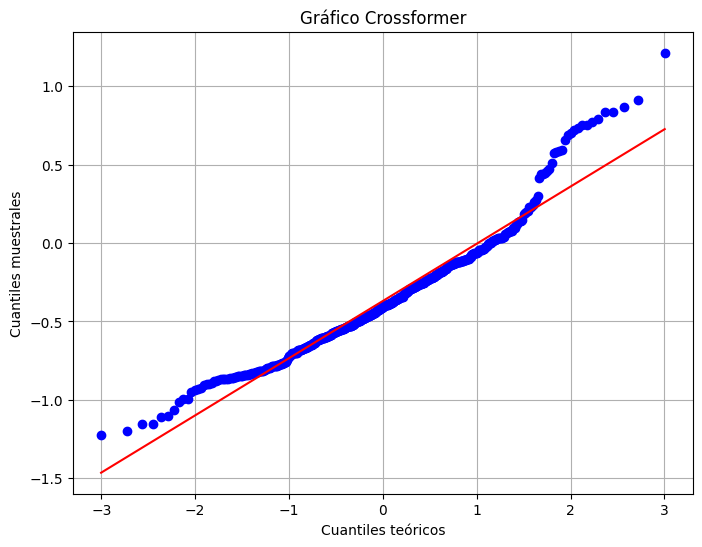

In [23]:
plt.figure(figsize=(8, 6))

stats.probplot(final["Crossformer"], dist="norm", plot=plt)
plt.title('Gráfico Crossformer')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

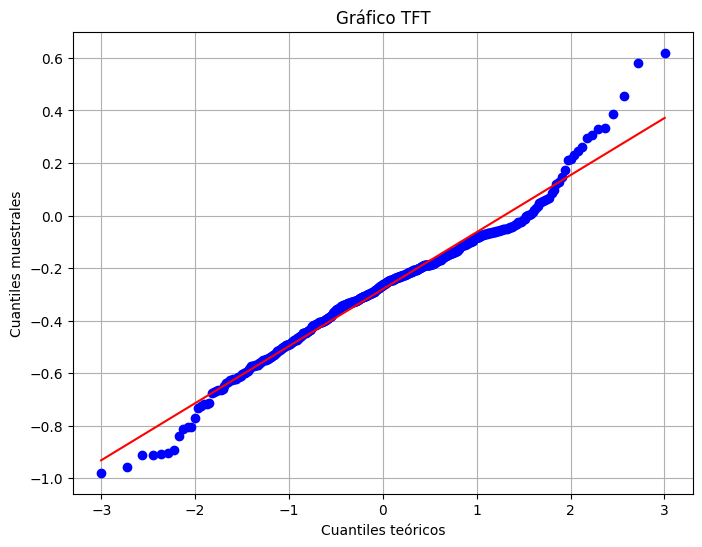

In [24]:
plt.figure(figsize=(8, 6))

stats.probplot(final["TFT"], dist="norm", plot=plt)
plt.title('Gráfico TFT')
plt.xlabel('Cuantiles teóricos')
plt.ylabel('Cuantiles muestrales')
plt.grid()
plt.show()

In [25]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

4.0848066833907365e-55


In [26]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.00131,0.01963,0.00393
1,MLP vs GRU,0.00000,0.00000,0.00000
2,MLP vs Crossformer,0.00000,0.00000,0.00000
3,MLP vs iTransformer,0.00000,0.00000,0.00000
4,MLP vs TFT,0.00000,0.00000,0.00000
5,LSTM vs GRU,0.00000,0.00000,0.00000
6,LSTM vs Crossformer,0.28691,1.00000,0.57383
7,LSTM vs iTransformer,0.00000,0.00000,0.00000
8,LSTM vs TFT,0.00000,0.00000,0.00000
9,GRU vs Crossformer,0.00029,0.00436,0.00145
